In [1]:
print("hello world")

hello world


In [2]:
import sys
sys.modules.pop('feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)
sys.modules.pop('utils.models_and_metrics', None)

In [12]:
from utils.feature_loader import load_feature_lists
from utils.data_quality import nettoyer_nan_par_colonne
# from utils.data_quality import nettoyer_lignes_vides
import pandas as pd
df_groh = pd.read_excel(r"C:\Users\romai\Desktop\travail\Copie de BAZEA.xlsx")
# taux de Nan
# for col in df_groh.columns:
#     print(round(df_groh[col].isna().mean(),2),col, )
# df_groh,index_a_drop = nettoyer_lignes_vides(df_groh)
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)
features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]]
features_etiology = df_groh[feature_lists["features_etiology"]]
features_death = df_groh[feature_lists["death"]]
# print(features_grroh.columns)


In [14]:
df_groh

,Study,PATIENT,CENTRE,SEXE,DATNAI,age,DATINC,DATADMHOSPI,DATADMREA,DSORTREA,...,Pathog√®ne.1.bis,Pathog√®ne.2.bis,Pathog√®ne.3.bis,DIAGNOSTIC.DEF.1.x,DIAGNOSTIC.DEF.2.x,DIAGNOSTIC.DEF.3.x,PATHOGENE.DEF.1,PATHOGENE.DEF.2,PATHOGENE.DEF.3,Unnamed: 194
0,TRIALOH,01001FF,1,0.0,1954-03-03,55.000000,2009-11-16,2009-10-29,2009-11-13 00:00:00,2009-11-19,...,CD,NaN,NaN,ABDOMEN,NaN,NaN,GRAMPLUS,NaN,NaN,01001FF
1,TRIALOH,01002DM,1,1.0,1959-09-10,50.000000,2009-11-19,2009-10-24,2009-11-06 00:00:00,2009-12-02,...,Enterobacter,Pseudomonas,NaN,SAM,PNEUMONIE,NaN,GRAMMOINS,GRAMMOINS,NaN,01002DM
2,TRIALOH,01003GJ,1,1.0,1951-09-09,58.000000,2009-11-19,2009-11-13,2009-11-16 00:00:00,2009-11-20,...,NaN,NaN,NaN,ABDOMEN,NaN,NaN,NaN,NaN,NaN,01003GJ
3,TRIALOH,01004QC,1,0.0,1970-02-27,39.000000,2009-11-20,2009-11-19,2009-11-19 00:00:00,2009-11-28,...,NaN,NaN,NaN,AVC,LEUCOSTASE,NaN,NaN,NaN,NaN,01004QC
4,TRIALOH,01005TA,1,0.0,1951-02-21,58.000000,2009-11-25,2006-10-16,2009-11-23 00:00:00,2009-11-29,...,NaN,NaN,NaN,PNEUMONIE,NaN,NaN,NaN,NaN,NaN,01005TA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4133,baloh,NaN,15,1.0,1950-06-16,54.026010,NaT,2004-06-25,2004-07-05 00:00:00,2004-07-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4134,baloh,NaN,15,1.0,1946-09-18,57.598905,NaT,2004-04-24,2004-05-09 00:00:00,2004-05-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4135,baloh,NaN,15,1.0,1935-03-27,68.873374,NaT,2004-02-09,2004-02-10 00:00:00,2004-02-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4136,baloh,NaN,15,0.0,1944-03-05,60.993840,NaT,2005-03-03,2005-03-03 00:00:00,2005-03-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
from utils.data_quality import nettoyer_lignes_vides
from utils.feature_transformer import transform_features
sys.modules.pop('utils.utils_grroh',None)
from utils.utils_grroh import construire_mapping_renommage,format_to_efraim,ensure_float_clip
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)

features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]+ feature_lists["features_etiology"] ]
mapping_df = construire_mapping_renommage(feature_lists["Liste_features_grroh"] +feature_lists["Liste_features_scan_radio"] + feature_lists["features_etiology"] )
df_renomme = format_to_efraim(features_grroh, mapping_df)
df_renomme = ensure_float_clip(df_renomme)
df_nb = df_renomme.select_dtypes(include="number")
# _ = df_nb.hist(figsize=(10,8))
L_fill_mediane = ["Age"	,
                  "Time H-ICU"	,
                  "TIME SYMPTOMES-ICU",
                  "Time  DG-ICU",
                  "SOFA_score",
                  "Temp",
                  "Charlson_index",
                  "SaO2",
                  "PaO2/FiO2 VALUE VALUE",
                  "Resp_rate",
                  "Leukocytes",
                  "Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in df_renomme.columns
}
grroh_clean = nettoyer_nan_par_colonne(df_renomme,strategie_fill_nan)
grroh_clean["Hem_mal"]  = grroh_clean["Hem_mal"] .fillna(0)

grroh_clean_transform = transform_features(grroh_clean)
grroh_clean_transform = grroh_clean_transform.drop(columns=['Leukocytes'])
# Enlever les non diag
L_diag = ['Bacterial infection', 'Viral infection',
'Invasive pulmonary aspergillosis', 'All fungus', 'Other fungal',
'Mucorales', 'Pneumocystis jirovecii infection',
'Cardiogenic pulmonary oedema', 'Disease-related infiltrates',
'Drug toxicity related', 'Other infection',
'Other non infectious causes']
L_features = [x for x in grroh_clean_transform if x not in L_diag]
grroh_diag = grroh_clean_transform[L_diag]

grroh_diag,index_a_drop = nettoyer_lignes_vides(grroh_diag)
grroh_clean_transform = grroh_clean_transform.drop(index=index_a_drop)
grroh_features = grroh_clean_transform[L_features]
grroh_clean_transform = pd.concat([grroh_features,grroh_diag],axis=1)

🔹 Age → NaN remplacés par la médiane (63.0)
🔹 Time H-ICU → NaN remplacés par la médiane (6.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (1.0)
🔹 Time  DG-ICU → NaN remplacés par la médiane (199.0)
🔹 Charlson_index → NaN remplacés par la médiane (5.0)
🔹 SOFA_score → NaN remplacés par la médiane (6.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SaO2 → NaN remplacés par la médiane (0.92)
🔹 Temp → NaN remplacés par la médiane (38.1)
🔹 Leukocytes → NaN remplacés par la médiane (8.2)
🔹 Quad_no → NaN remplacés par la médiane (2.0)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (149.0)

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 1106


c:\Users\romai\Desktop\codes\respiratory_diagnostics\utils\feature_transformer.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["GvHD"] >= 1,"GvHD"] = 1


In [15]:
grroh_diag

,Bacterial infection,Viral infection,Invasive pulmonary aspergillosis,All fungus,Other fungal,Mucorales,Pneumocystis jirovecii infection,Cardiogenic pulmonary oedema,Disease-related infiltrates,Drug toxicity related,Other infection,Other non infectious causes
2,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,True,False,False,False
6,False,False,False,True,False,False,False,False,False,False,False,False
7,True,False,False,False,False,False,False,False,False,False,False,False
9,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4121,True,False,False,False,False,False,False,False,False,False,False,False
4122,False,True,False,False,False,False,False,False,False,False,False,False
4123,True,False,False,False,False,False,False,False,False,False,False,False
4128,True,False,False,False,False,False,False,False,False,False,False,False


In [16]:
1106 - 159

947

In [12]:
grroh_diag.iloc[1876]

Bacterial infection                 False
Viral infection                      True
Invasive pulmonary aspergillosis     True
All fungus                          False
Other fungal                        False
Mucorales                           False
Pneumocystis jirovecii infection    False
Cardiogenic pulmonary oedema        False
Disease-related infiltrates         False
Drug toxicity related               False
Other infection                     False
Other non infectious causes         False
Name: 2589, dtype: bool

<Axes: >

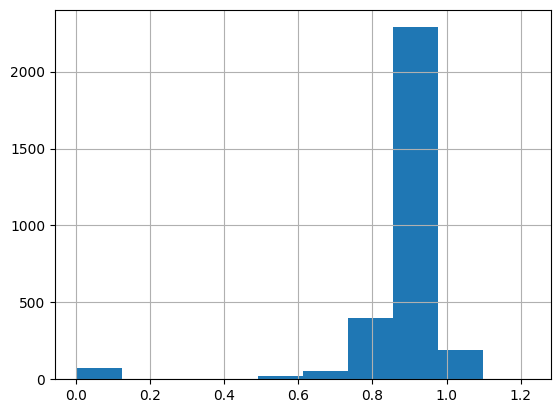

In [13]:
df_groh[df_groh["PAO2FIO2_meca"]>0]
df_float = ensure_float_clip(df_groh)
grroh_clean_transform["SaO2"].hist()

In [14]:
grroh_clean_transform
grroh_clean_transform[grroh_clean_transform["PaO2/FiO2 VALUE VALUE"]>0]

,Time H-ICU,TIME SYMPTOMES-ICU,Time DG-ICU,HSCT_BMT_Allograft,HSCT_BMT_Autograft,Sys_dis,Solid_tumor,Organ_transpl,Immuno_drugs,Steroids_YN,...,Invasive pulmonary aspergillosis,All fungus,Other fungal,Mucorales,Pneumocystis jirovecii infection,Cardiogenic pulmonary oedema,Disease-related infiltrates,Drug toxicity related,Other infection,Other non infectious causes
2,0.666667,0.000000,0.916667,0.0,0.0,0,0,0,False,1.0,...,False,False,False,False,False,False,False,False,False,True
3,0.000000,0.900000,0.000000,0.0,0.0,0,0,0,False,1.0,...,False,False,False,False,False,False,True,False,False,False
6,0.983051,0.000000,0.983051,0.0,0.0,0,0,0,False,1.0,...,False,True,False,False,False,False,False,False,False,False
7,0.000000,0.500000,0.997260,0.0,0.0,0,0,0,False,0.0,...,False,False,False,False,False,False,False,False,False,False
9,0.666667,0.000000,0.994764,0.0,0.0,0,0,0,False,0.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4121,0.916667,0.500000,0.916667,0.0,0.0,0,0,1,True,0.0,...,False,False,False,False,False,False,False,False,False,False
4122,0.500000,0.857143,0.997260,0.0,0.0,0,0,1,True,0.0,...,False,False,False,False,False,False,False,False,False,False
4123,0.916667,0.000000,0.997260,0.0,0.0,0,0,1,True,0.0,...,False,False,False,False,False,False,False,False,False,False
4128,0.000000,0.916667,0.997085,0.0,0.0,0,0,1,True,1.0,...,False,False,False,False,False,False,False,False,False,False


In [15]:
df_bool = df_renomme.select_dtypes(include="bool")
print(df_bool.mean())

GvHD                                0.000483
Ibr_Flu_Met                         0.003383
Sex                                 0.379410
Chemotherapy                        0.265104
Bacterial infection                 0.293862
Viral infection                     0.092315
Invasive pulmonary aspergillosis    0.024166
All fungus                          0.033833
Other fungal                        0.014500
Mucorales                           0.000725
Pneumocystis jirovecii infection    0.050749
Cardiogenic pulmonary oedema        0.087965
Disease-related infiltrates         0.074674
Drug toxicity related               0.023441
Other infection                     0.019816
Other non infectious causes         0.083615
dtype: float64


# Efraim 

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists, load_diagnostic_feature_map
import sys
# loads the col
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# separer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')

diagnostic_feature_map = load_diagnostic_feature_map(
    FEATURE_CONFIG_PATH,
    available_columns=df.columns,
    diagnoses = ["default"] #"Bacterial infection", # A changer pour bacterial !!! 
)
all_feature_columns = []
for columns_list in diagnostic_feature_map.values():
    for feature_name in columns_list:
        if feature_name not in all_feature_columns:
            all_feature_columns.append(feature_name)
Liste_features = all_feature_columns
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_death = df[features_death]
DIAGNOSTIC_FEATURES = diagnostic_feature_map
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score",
                  "Neutrophils","Temp","SpO2","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no","Charlson_index"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
strategie_fill_nan["DG1"] = "str"
strategie_fill_nan["DG2"] = "str"
strategie_fill_nan["Sys_dis_spec"] = "str"
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'All fungus' : ["Other fungal ",'Mucorales'],
                    'Other fungal' :["Other fungal "] ,
                    'Mucorales' : ['Mucorales'],
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug toxicity related' : ['Drug toxicity related'],
                    'Other infection' : ['Other infection '],
                    'Other non infectious causes': ['Other non infectious causes','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")


🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 Charlson_index → NaN remplacés par la médiane (5.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SpO2 → NaN remplacés par la médiane (92.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)
⚠️ Colonne 'DG1' absente du DataFrame, ignorée.
⚠️ Colonne 'DG2' absente du DataFrame, ignorée.
⚠️ Colonne 'Sys_dis_spec' absente du DataFrame, ignorée.

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055


# Comparasion des valeurs 

In [17]:
df_groh['age'].max()

np.float64(94.0)

In [18]:
sys.modules.pop('utils.data_quality',None)
from utils.data_quality import compare_columns
df_with_diag = pd.concat([df_features_clean,df_labels_fusion],axis=1)

compare_columns(df_with_diag,grroh_clean_transform)

Colonnes uniquement dans df1 :
set()

Colonnes uniquement dans df2 :
set()


[HSCT_BMT_Allograft] variable binaire ignoree (|Delta| < 5.0 pts)
[HSCT_BMT_Autograft] variable binaire ignoree (|Delta| < 5.0 pts)
[Sys_dis] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 5239/6360 (82.37%) vs 2781/3032 (91.72%) -> diff -9.35 pts (10.2% de la valeur max 91.72%)
    valeur=np.int64(1): 1121/6360 (17.63%) vs 251/3032 (8.28%) -> diff +9.35 pts (53.0% de la valeur max 17.63%)
[Solid_tumor] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 3950/6360 (62.11%) vs 2179/3032 (71.87%) -> diff -9.76 pts (13.6% de la valeur max 71.87%)
    valeur=np.int64(1): 2410/6360 (37.89%) vs 853/3032 (28.13%) -> diff +9.76 pts (25.8% de la valeur max 37.89%)
[Organ_transpl] variable binaire ignoree (|Delta| < 5.0 pts)
[Immuno_drugs] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 3886/6360 (61.10%) vs 2363/3032 (77.94%) -> diff -16.83 pts (21.6% de la valeur max 77.94%)
    valeur=np.int64(1): 2474/6360 (38.90%) vs 669/3032 (22.06%) -> diff +16.83 pts (43.3% 

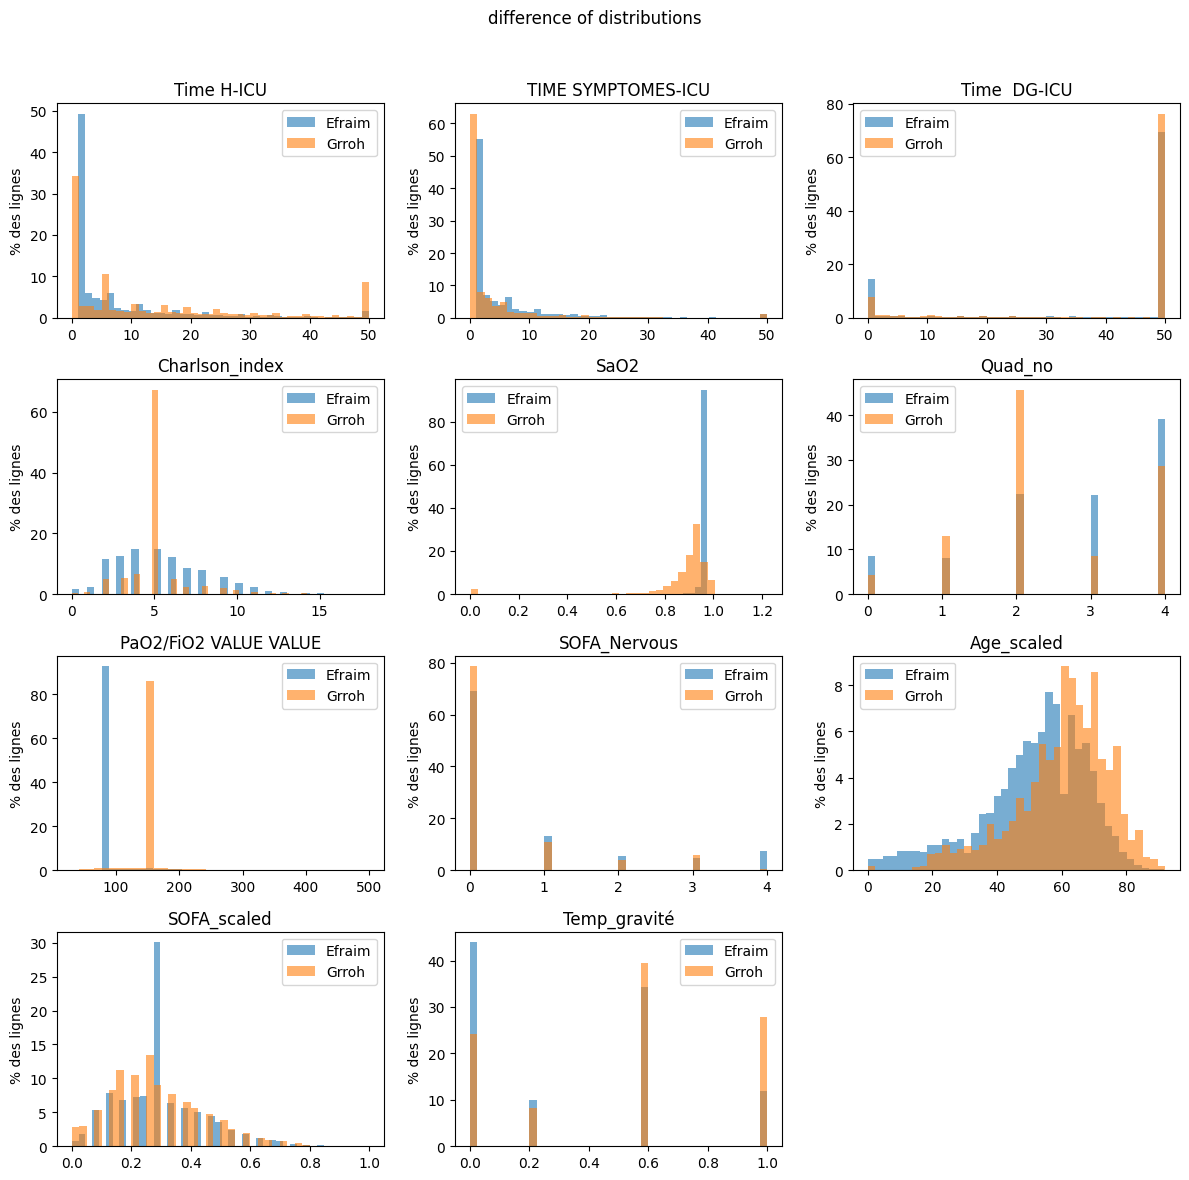

In [19]:
sys.modules.pop("utils.data_quality",None)
from utils.data_quality import plot_column_histograms

fig, axes = plot_column_histograms(
    df_left=df_with_diag,
    df_right=grroh_clean_transform,
    columns=grroh_clean_transform.columns,
    bins=40,
    label_left="Efraim",
    label_right="Grroh",
    suptitle="difference of distributions"
)
plt.show()

# performance sur les données du grroh

In [ ]:
model_loaded

{'diagnostic': 'Pneumocystis jirovecii infection',
 'saved_at': '2026-03-26T14:46:39.489491Z',
 'pipe_train': Pipeline(steps=[('scaler',
                  AutoStandardScaler(colonnes_numeriques=['Sex', 'Time H-ICU',
                                                          'TIME SYMPTOMES-ICU',
                                                          'Time  DG-ICU', 'GvHD',
                                                          'Sys_dis',
                                                          'Solid_tumor',
                                                          'Organ_transpl',
                                                          'Chemotherapy',
                                                          'Ibr_Flu_Met',
                                                          'Immuno_drugs',
                                                          'Tar_ther',
                                                          'Immunotherapy',
                                       

: 

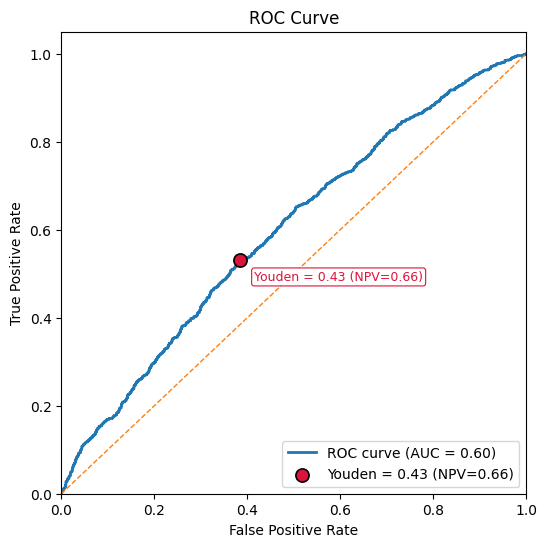

ROC AUC = 0.60
Negative Predictive Value youden: 0.6621221102548903 threshold 0.4277050119940134


c:\Users\romai\Desktop\codes\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\romai\Desktop\codes\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    h

==== Bacterial infection (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 6/10 (seed=47)

📊 Répartition des classes : pos=0.436, neg=0.564
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajo

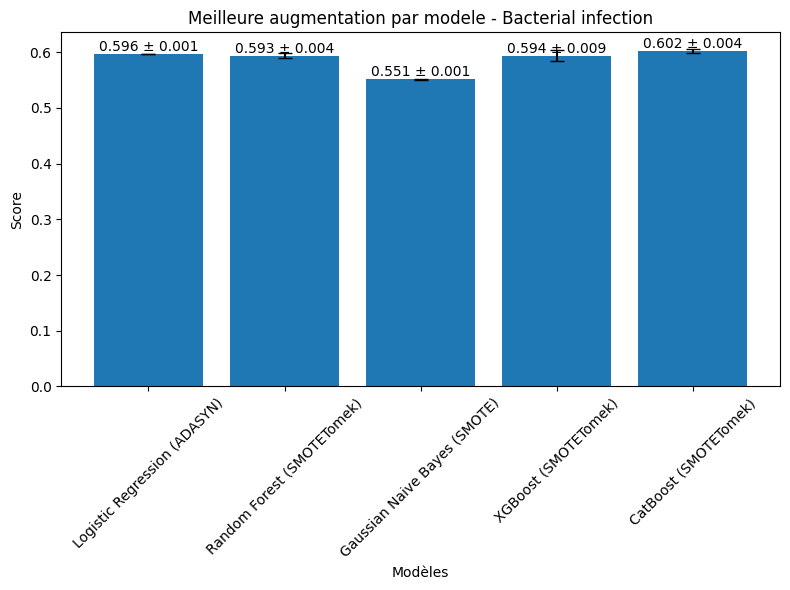


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (ADASYN) - roc_auc moyen = 0.5964 +/- 0.0005 | seuil Youden = 0.3012
- Random Forest (SMOTETomek) - roc_auc moyen = 0.5934 +/- 0.0043 | seuil Youden = 0.4167
- Gaussian Naive Bayes (SMOTE) - roc_auc moyen = 0.5509 +/- 0.0008 | seuil Youden = 0.4448
- XGBoost (SMOTETomek) - roc_auc moyen = 0.5936 +/- 0.0093 | seuil Youden = 0.4482
- CatBoost (SMOTETomek) - roc_auc moyen = 0.6016 +/- 0.0036 | seuil Youden = 0.4448


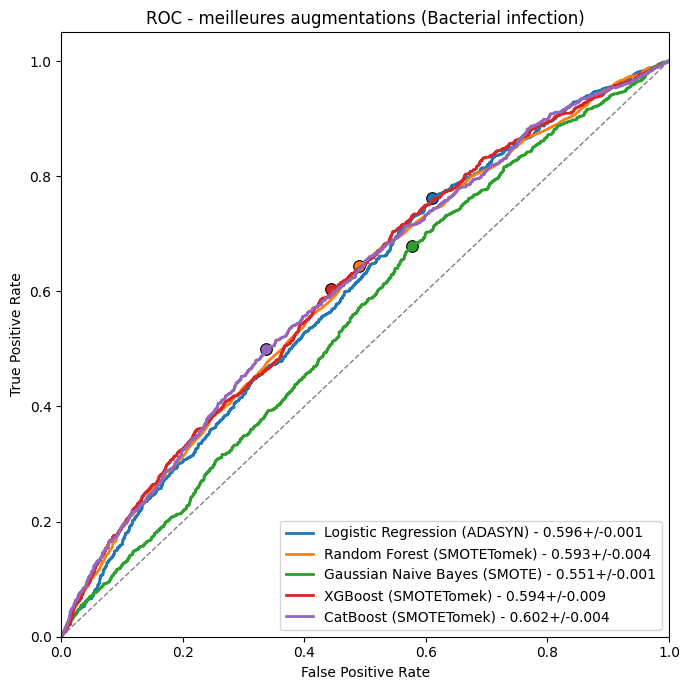

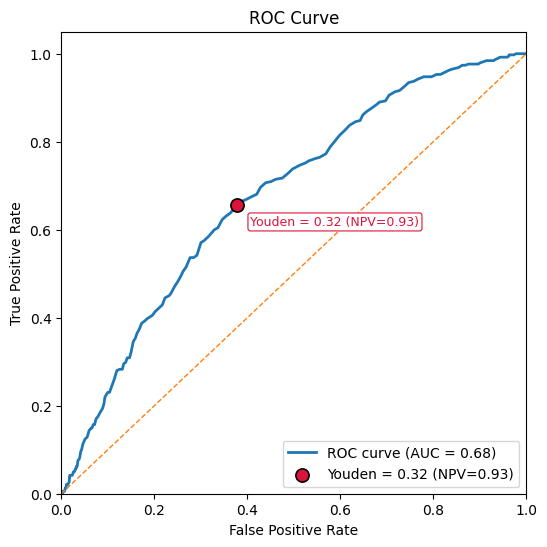

ROC AUC = 0.68
Negative Predictive Value youden: 0.9242590559824369 threshold 0.3233333333333333
==== Viral infection (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.289, neg=0.711
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.289, neg=0.711
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.289, neg=0.711
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.289, neg=0.711
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.289, neg=0.711
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 6/10 (seed=47)

📊 Répartition des classes : pos=0.

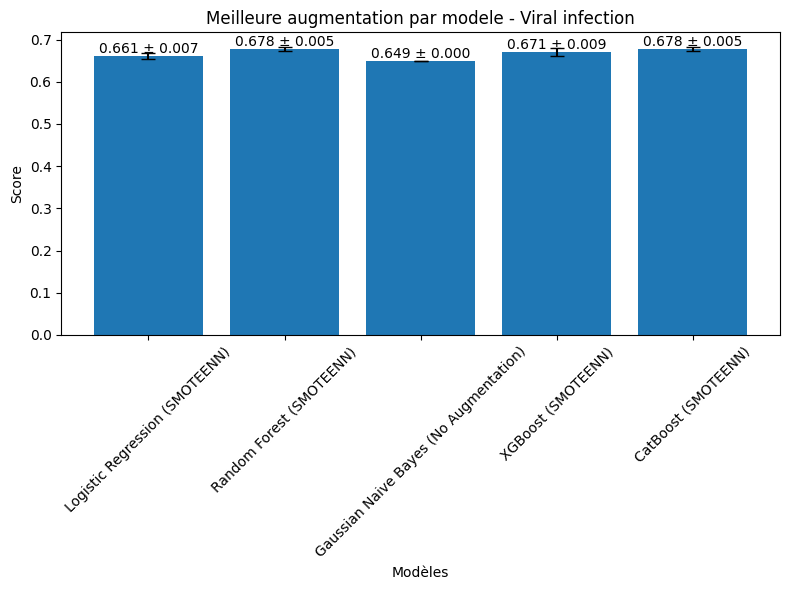


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (SMOTEENN) - roc_auc moyen = 0.6609 +/- 0.0069 | seuil Youden = 0.7070
- Random Forest (SMOTEENN) - roc_auc moyen = 0.6783 +/- 0.0045 | seuil Youden = 0.5533
- Gaussian Naive Bayes (No Augmentation) - roc_auc moyen = 0.6491 +/- 0.0000 | seuil Youden = 0.0111
- XGBoost (SMOTEENN) - roc_auc moyen = 0.6711 +/- 0.0090 | seuil Youden = 0.3445
- CatBoost (SMOTEENN) - roc_auc moyen = 0.6785 +/- 0.0046 | seuil Youden = 0.2595


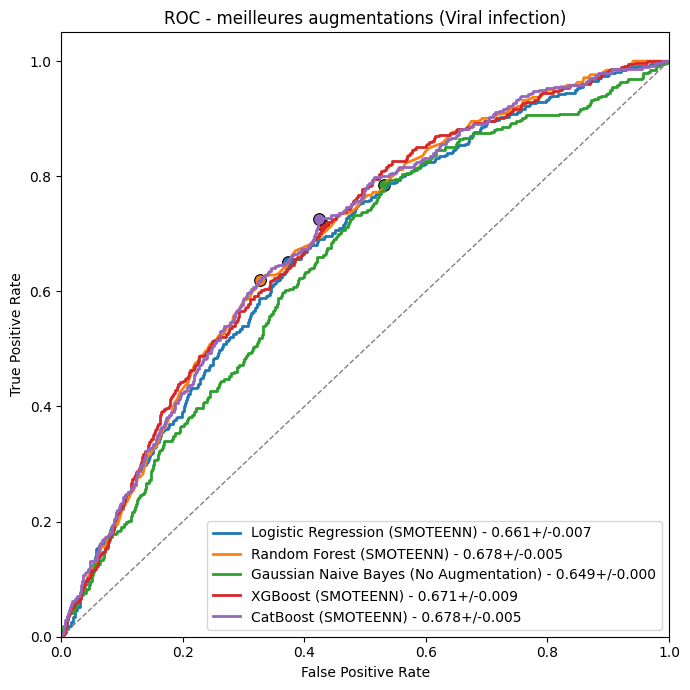

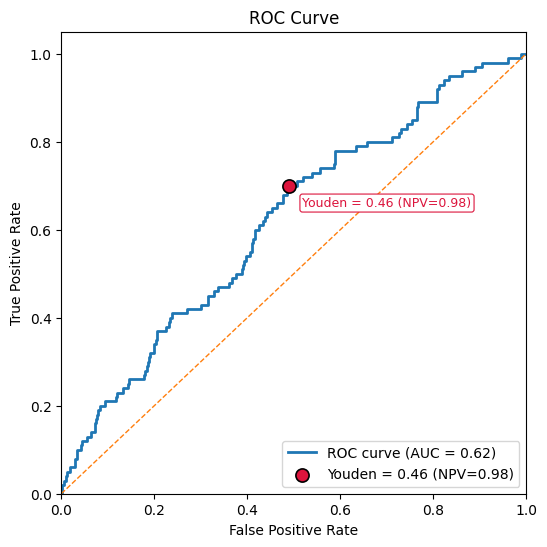

ROC AUC = 0.62
Negative Predictive Value youden: 0.9797385620915032 threshold 0.4598351922428192
==== Invasive pulmonary aspergillosis (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing



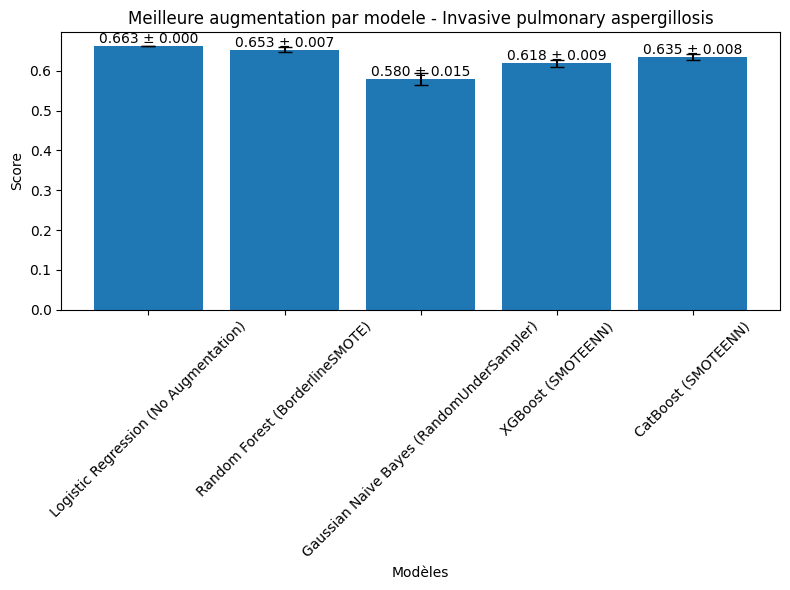


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (No Augmentation) - roc_auc moyen = 0.6634 +/- 0.0000 | seuil Youden = 0.4507
- Random Forest (BorderlineSMOTE) - roc_auc moyen = 0.6533 +/- 0.0073 | seuil Youden = 0.1033
- Gaussian Naive Bayes (RandomUnderSampler) - roc_auc moyen = 0.5796 +/- 0.0155 | seuil Youden = 0.0000
- XGBoost (SMOTEENN) - roc_auc moyen = 0.6184 +/- 0.0089 | seuil Youden = 0.0911
- CatBoost (SMOTEENN) - roc_auc moyen = 0.6349 +/- 0.0077 | seuil Youden = 0.0837


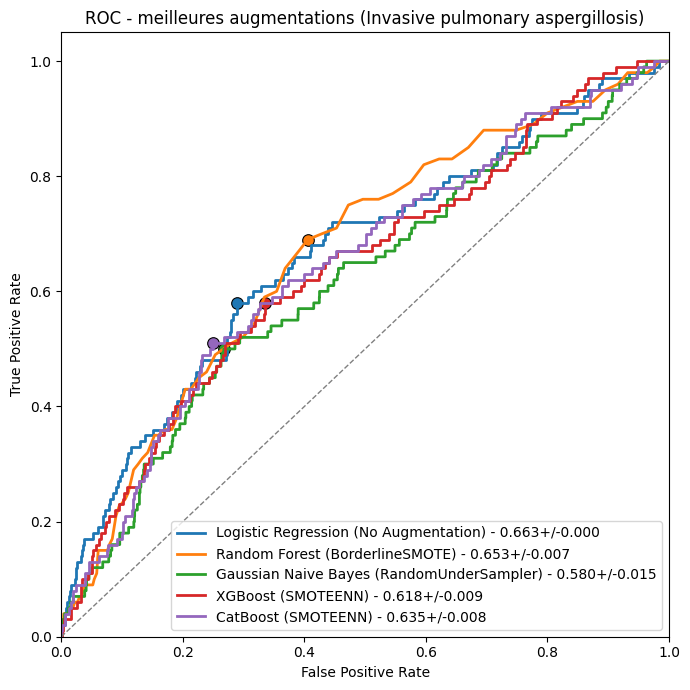

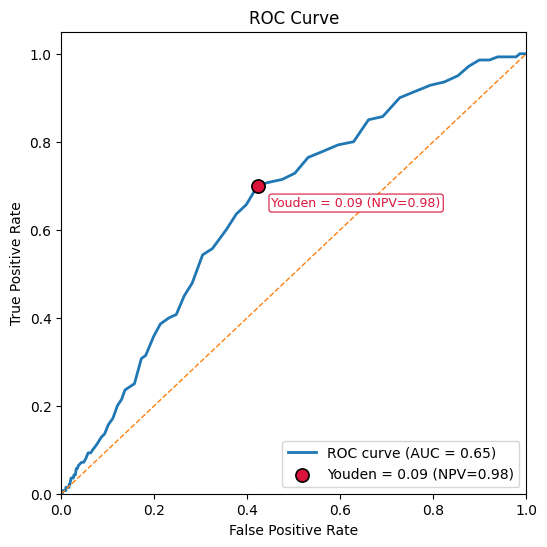

ROC AUC = 0.65
Negative Predictive Value youden: 0.9731693683622136 threshold 0.08666666666666667
==== All fungus (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.054, neg=0.946
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.054, neg=0.946
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.054, neg=0.946
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.054, neg=0.946
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.054, neg=0.946
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 6/10 (see

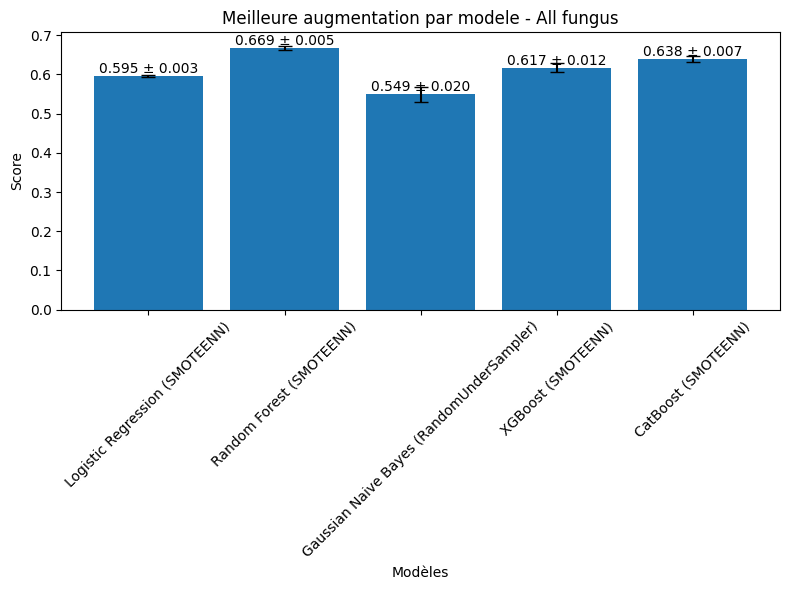


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (SMOTEENN) - roc_auc moyen = 0.5949 +/- 0.0026 | seuil Youden = 0.2536
- Random Forest (SMOTEENN) - roc_auc moyen = 0.6685 +/- 0.0051 | seuil Youden = 0.1400
- Gaussian Naive Bayes (RandomUnderSampler) - roc_auc moyen = 0.5493 +/- 0.0196 | seuil Youden = 0.0486
- XGBoost (SMOTEENN) - roc_auc moyen = 0.6174 +/- 0.0117 | seuil Youden = 0.0043
- CatBoost (SMOTEENN) - roc_auc moyen = 0.6383 +/- 0.0075 | seuil Youden = 0.0178


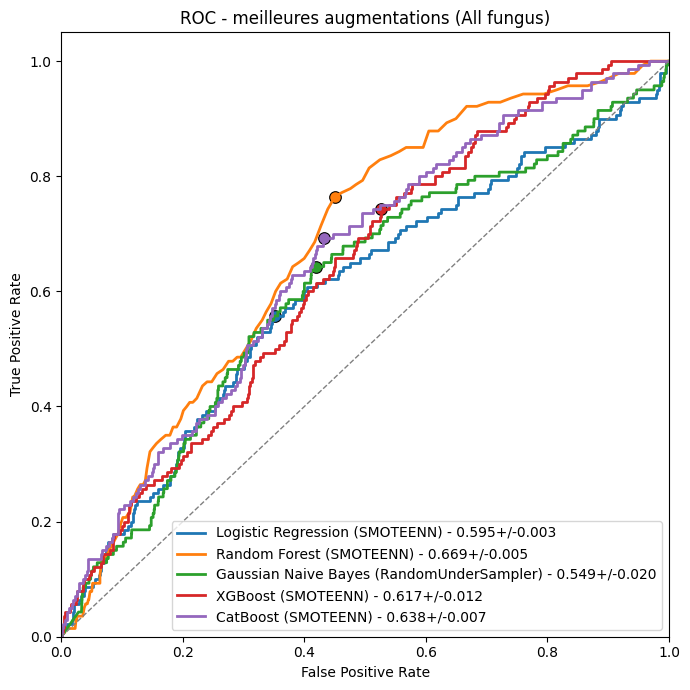

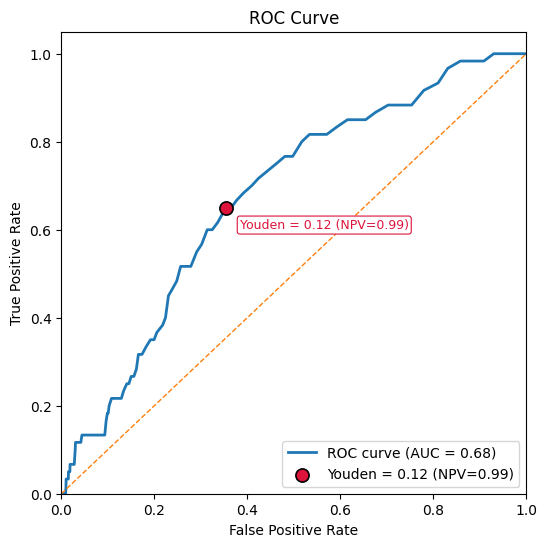

ROC AUC = 0.68
Negative Predictive Value youden: 0.9884711779448622 threshold 0.12
==== Other fungal (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 6/10 (seed=47)

📊 Répa

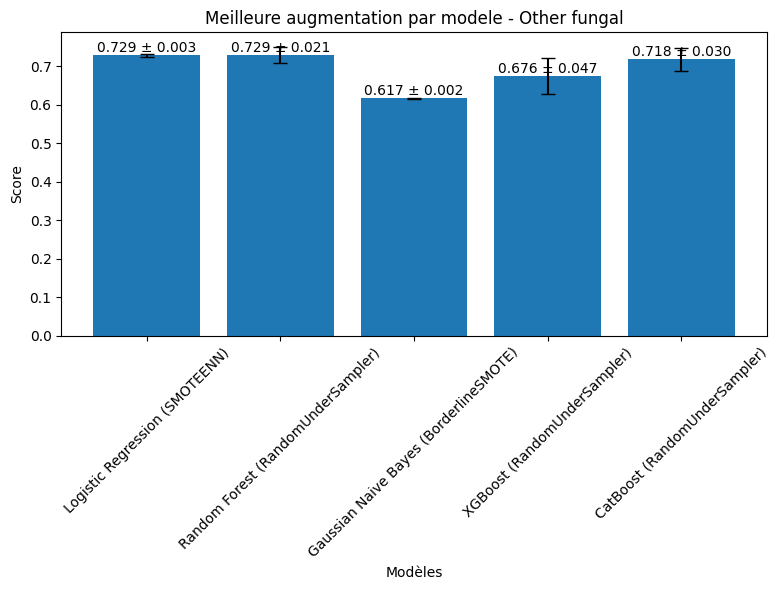


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (SMOTEENN) - roc_auc moyen = 0.7285 +/- 0.0034 | seuil Youden = 0.2296
- Random Forest (RandomUnderSampler) - roc_auc moyen = 0.7291 +/- 0.0215 | seuil Youden = 0.4067
- Gaussian Naive Bayes (BorderlineSMOTE) - roc_auc moyen = 0.6165 +/- 0.0022 | seuil Youden = 0.0095
- XGBoost (RandomUnderSampler) - roc_auc moyen = 0.6757 +/- 0.0469 | seuil Youden = 0.7138
- CatBoost (RandomUnderSampler) - roc_auc moyen = 0.7176 +/- 0.0295 | seuil Youden = 0.4056


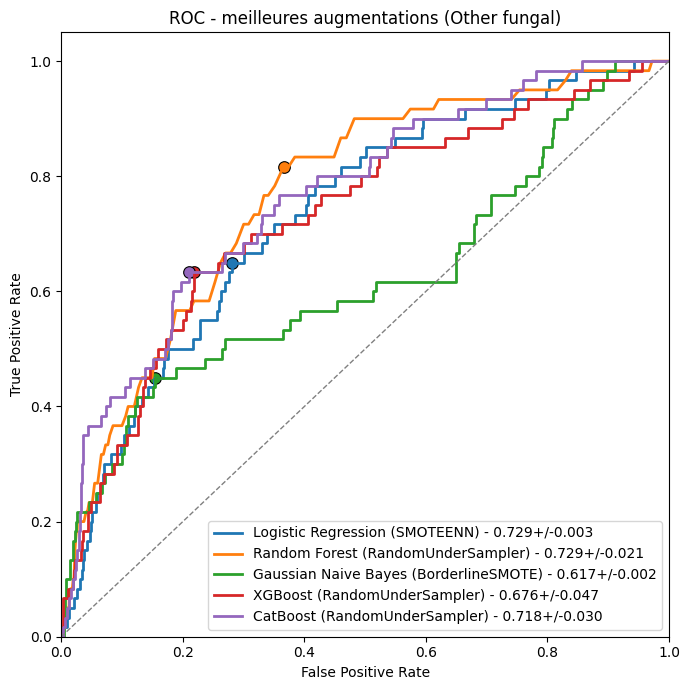

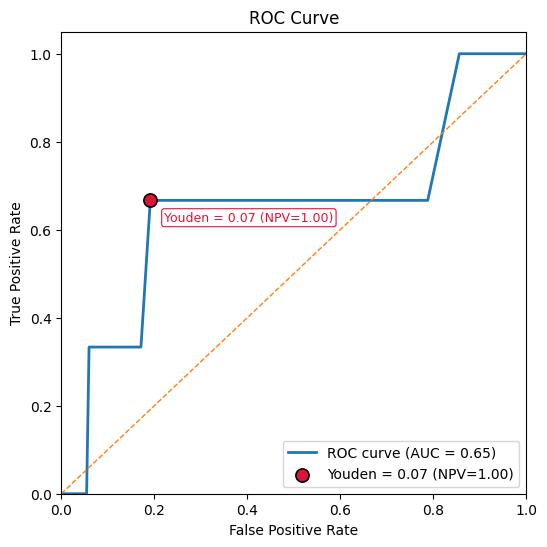

ROC AUC = 0.65
Negative Predictive Value youden: 0.9992038216560509 threshold 0.06666666666666667
==== Mucorales (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.014, neg=0.986
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.014, neg=0.986
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.014, neg=0.986
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.014, neg=0.986
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.014, neg=0.986
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 6/10 (seed

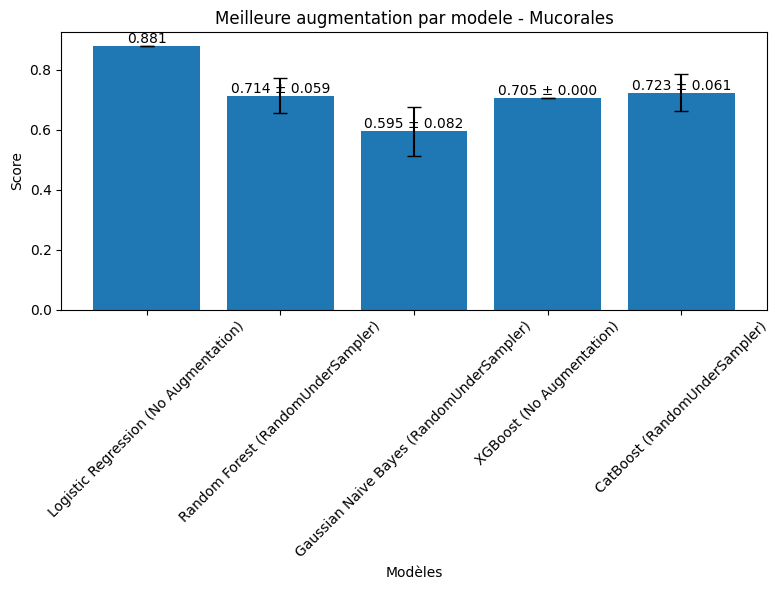


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (No Augmentation) - roc_auc moyen = 0.8810 +/- 0.0000 | seuil Youden = 0.4406
- Random Forest (RandomUnderSampler) - roc_auc moyen = 0.7143 +/- 0.0592 | seuil Youden = 0.4833
- Gaussian Naive Bayes (RandomUnderSampler) - roc_auc moyen = 0.5946 +/- 0.0816 | seuil Youden = 0.0000
- XGBoost (No Augmentation) - roc_auc moyen = 0.7054 +/- 0.0000 | seuil Youden = 0.0002
- CatBoost (RandomUnderSampler) - roc_auc moyen = 0.7235 +/- 0.0611 | seuil Youden = 0.4768


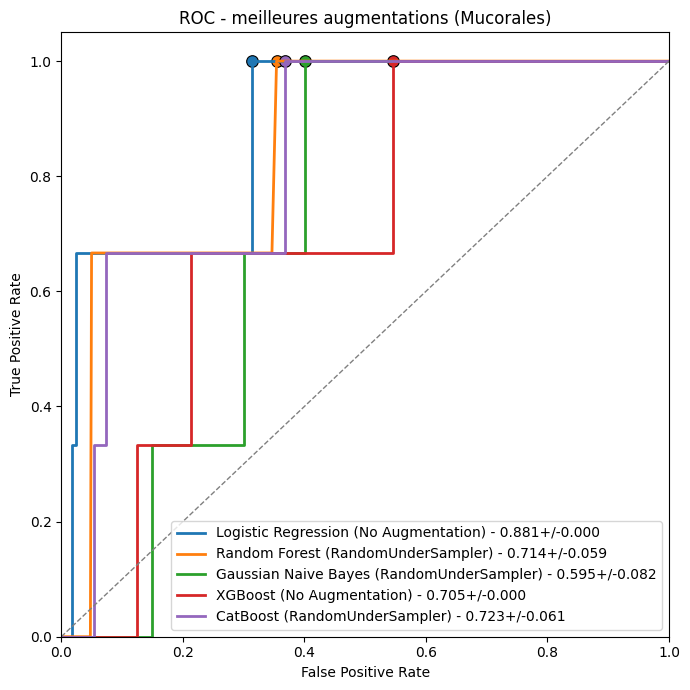

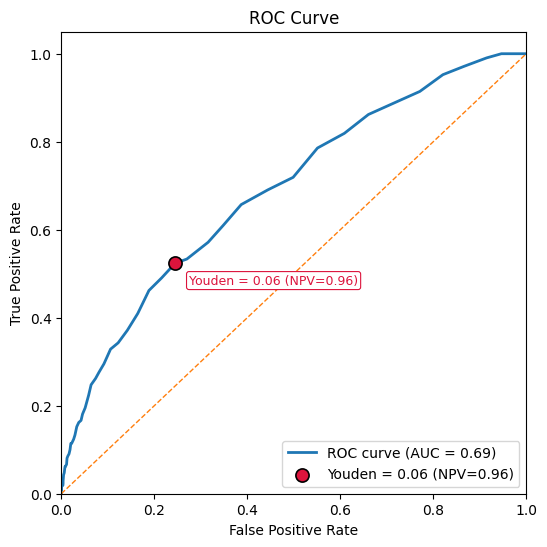

ROC AUC = 0.69
Negative Predictive Value youden: 0.9538793103448275 threshold 0.06333333333333334
==== Pneumocystis jirovecii infection (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.052, neg=0.948
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing


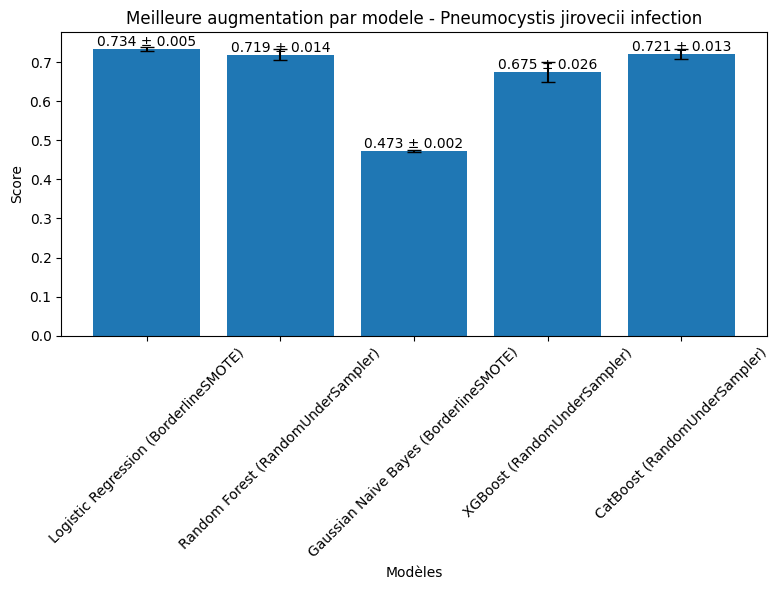


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (BorderlineSMOTE) - roc_auc moyen = 0.7344 +/- 0.0048 | seuil Youden = 0.2183
- Random Forest (RandomUnderSampler) - roc_auc moyen = 0.7193 +/- 0.0135 | seuil Youden = 0.5233
- Gaussian Naive Bayes (BorderlineSMOTE) - roc_auc moyen = 0.4725 +/- 0.0020 | seuil Youden = 0.0000
- XGBoost (RandomUnderSampler) - roc_auc moyen = 0.6752 +/- 0.0255 | seuil Youden = 0.8976
- CatBoost (RandomUnderSampler) - roc_auc moyen = 0.7212 +/- 0.0130 | seuil Youden = 0.5165


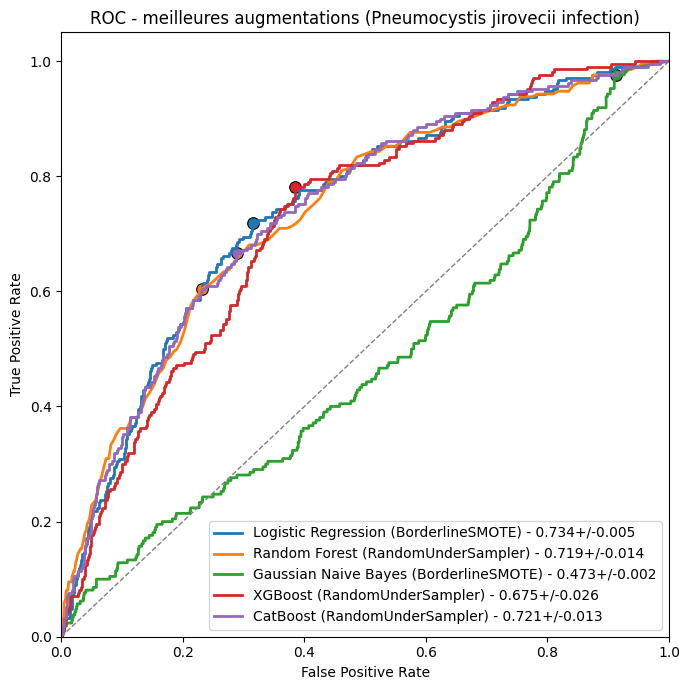

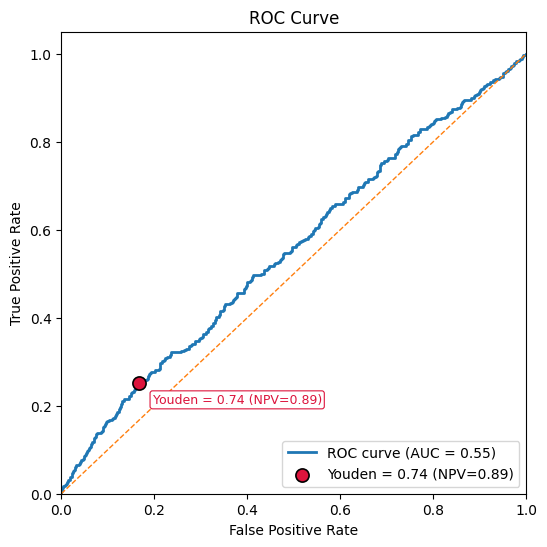

ROC AUC = 0.55
Negative Predictive Value youden: 0.8906688025630757 threshold 0.7394139589383525
==== Cardiogenic pulmonary oedema (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.132, neg=0.868
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.132, neg=0.868
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.132, neg=0.868
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.132, neg=0.868
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.132, neg=0.868
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 6/10 (seed=47)

📊 Répartition des cla

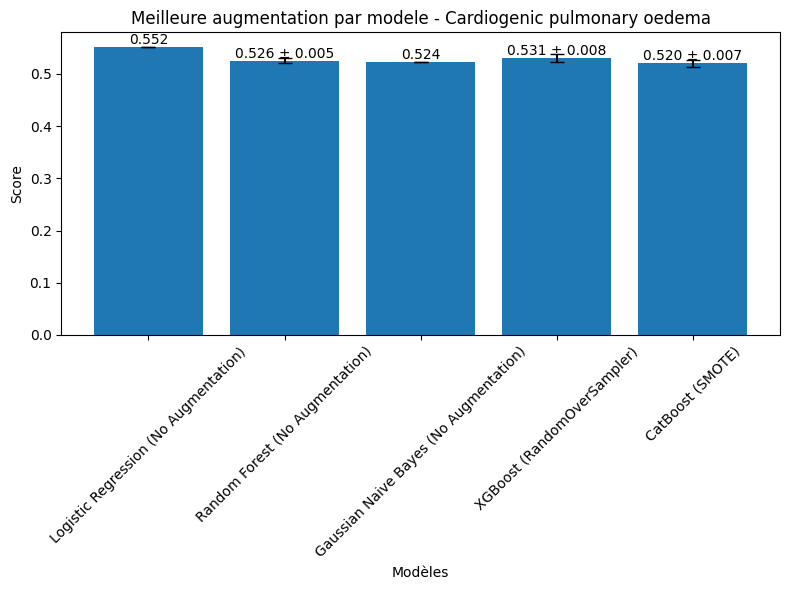


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (No Augmentation) - roc_auc moyen = 0.5522 +/- 0.0000 | seuil Youden = 0.2493
- Random Forest (No Augmentation) - roc_auc moyen = 0.5256 +/- 0.0052 | seuil Youden = 0.1567
- Gaussian Naive Bayes (No Augmentation) - roc_auc moyen = 0.5238 +/- 0.0000 | seuil Youden = 0.7471
- XGBoost (RandomOverSampler) - roc_auc moyen = 0.5309 +/- 0.0082 | seuil Youden = 0.0400
- CatBoost (SMOTE) - roc_auc moyen = 0.5202 +/- 0.0067 | seuil Youden = 0.2162


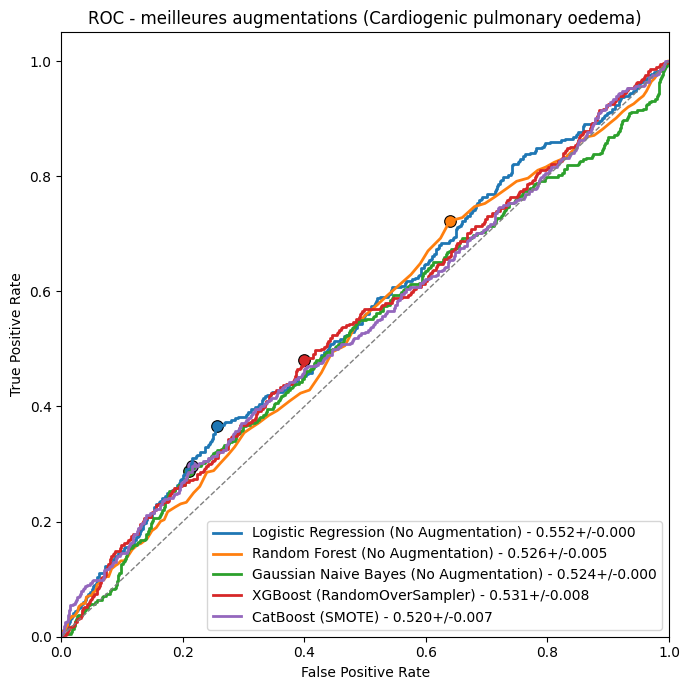

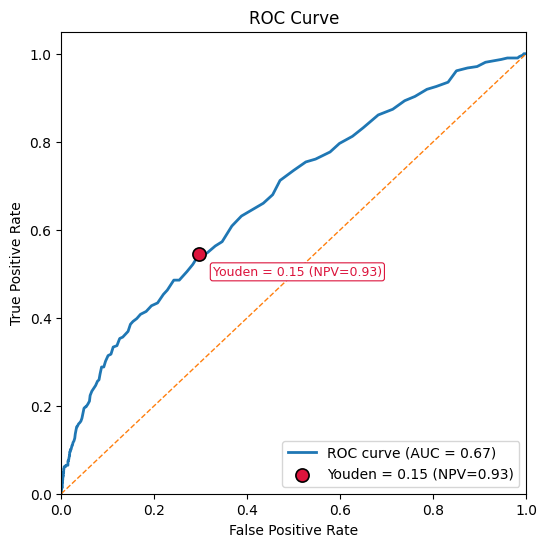

ROC AUC = 0.67
Negative Predictive Value youden: 0.9295573536411232 threshold 0.14666666666666667
==== Disease-related infiltrates (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.122, neg=0.878
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.122, neg=0.878
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.122, neg=0.878
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.122, neg=0.878
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.122, neg=0.878
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 6/10 (seed=47)

📊 Répartition des cla

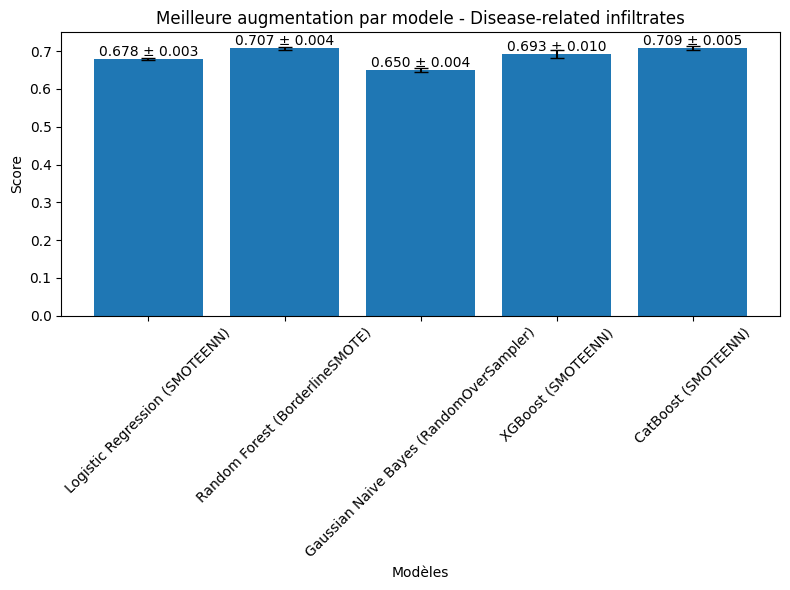


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (SMOTEENN) - roc_auc moyen = 0.6785 +/- 0.0033 | seuil Youden = 0.3037
- Random Forest (BorderlineSMOTE) - roc_auc moyen = 0.7072 +/- 0.0044 | seuil Youden = 0.1633
- Gaussian Naive Bayes (RandomOverSampler) - roc_auc moyen = 0.6502 +/- 0.0044 | seuil Youden = 0.6093
- XGBoost (SMOTEENN) - roc_auc moyen = 0.6927 +/- 0.0097 | seuil Youden = 0.0260
- CatBoost (SMOTEENN) - roc_auc moyen = 0.7090 +/- 0.0049 | seuil Youden = 0.0734


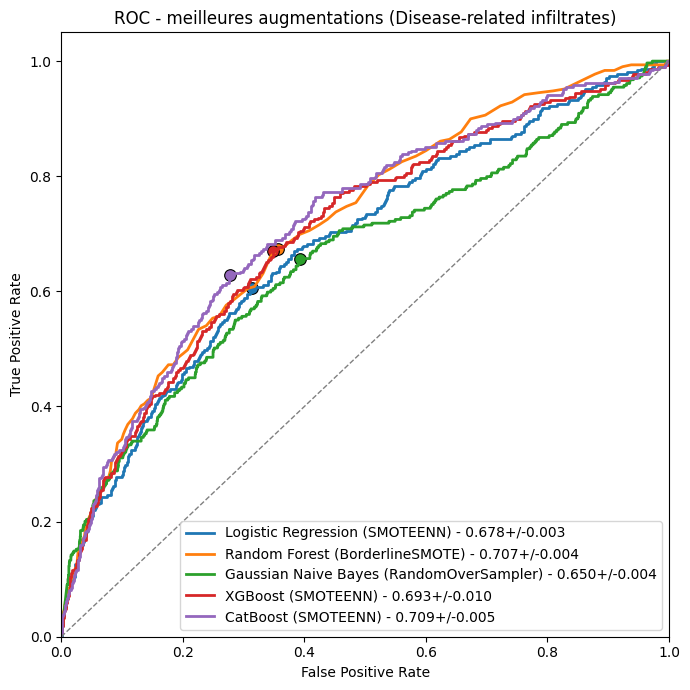

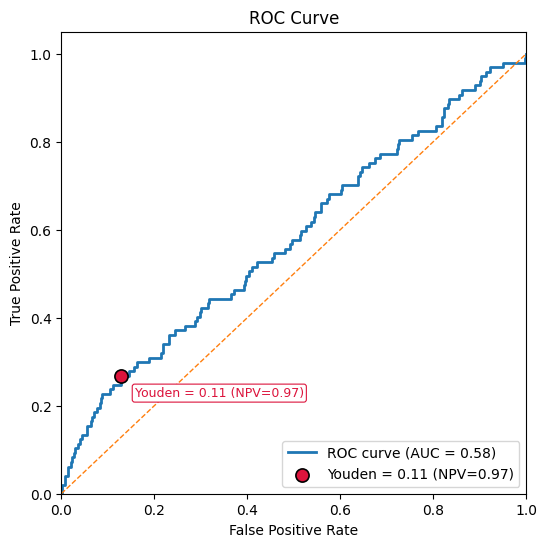

ROC AUC = 0.58
Negative Predictive Value youden: 0.9726339794754846 threshold 0.10816626922538577
==== Drug toxicity related (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.042, neg=0.958
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carl

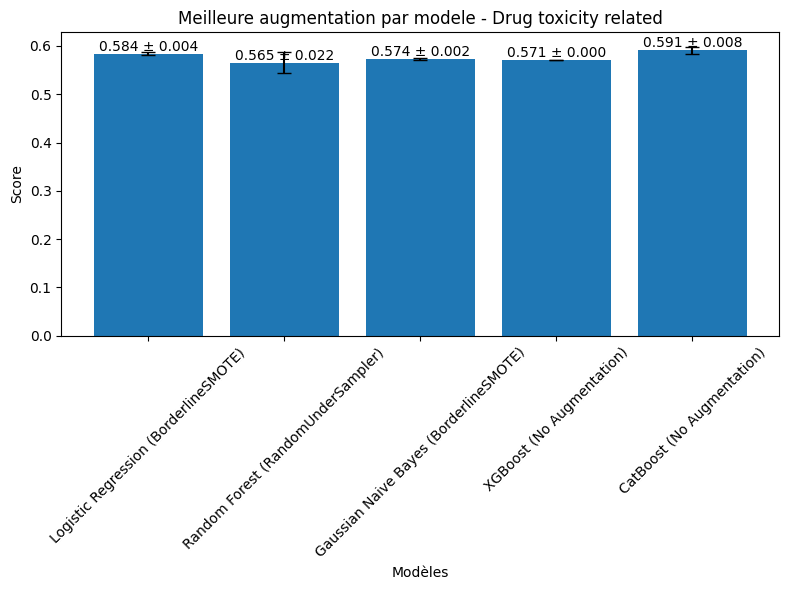


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (BorderlineSMOTE) - roc_auc moyen = 0.5838 +/- 0.0035 | seuil Youden = 0.3045
- Random Forest (RandomUnderSampler) - roc_auc moyen = 0.5652 +/- 0.0216 | seuil Youden = 0.4900
- Gaussian Naive Bayes (BorderlineSMOTE) - roc_auc moyen = 0.5736 +/- 0.0021 | seuil Youden = 0.9614
- XGBoost (No Augmentation) - roc_auc moyen = 0.5711 +/- 0.0000 | seuil Youden = 0.0020
- CatBoost (No Augmentation) - roc_auc moyen = 0.5907 +/- 0.0075 | seuil Youden = 0.0472


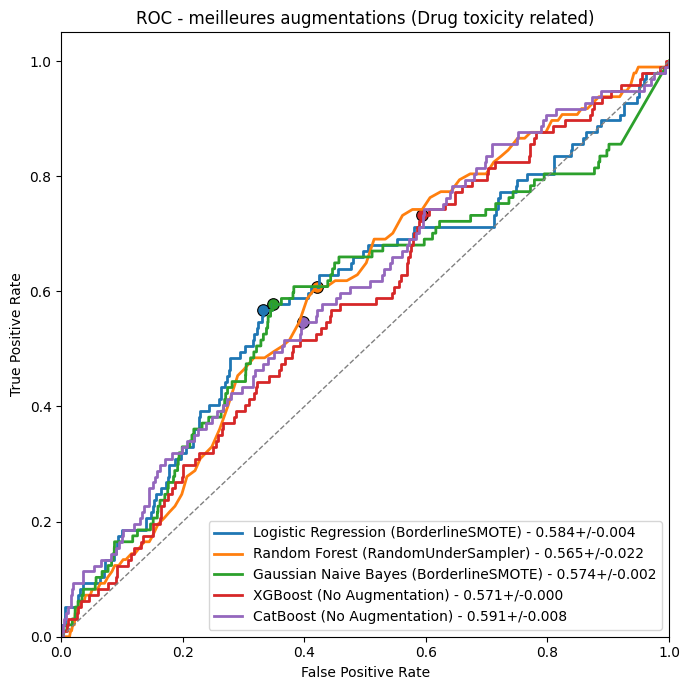

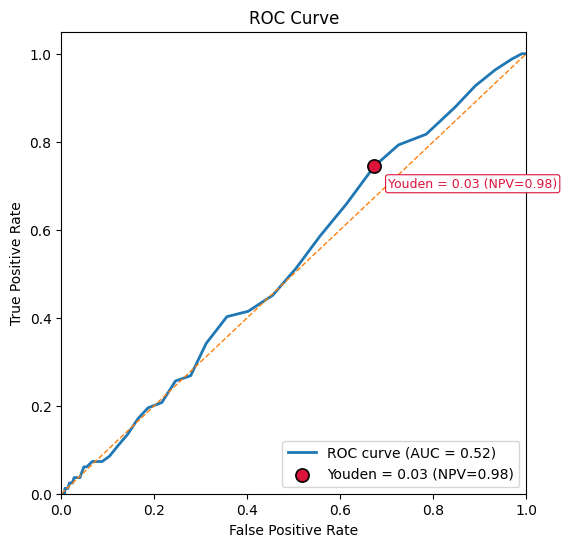

ROC AUC = 0.52
Negative Predictive Value youden: 0.9760479041916168 threshold 0.02666666666666667
==== Other infection (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.037, neg=0.963
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.037, neg=0.963
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.037, neg=0.963
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.037, neg=0.963
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.037, neg=0.963
⚖️ Dataset déséquilibré ? → True
🧪 Activation automatique du class_weight / auto-balancing

Monte Carlo 6/10

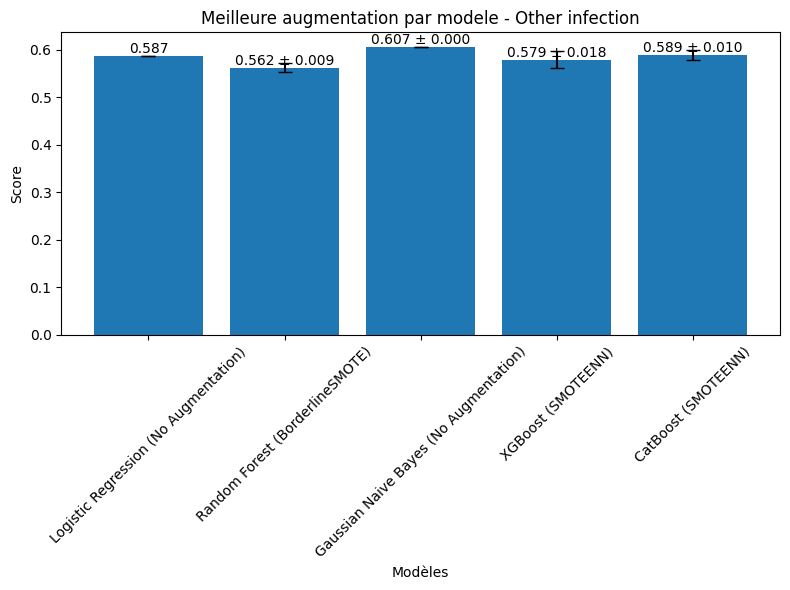


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (No Augmentation) - roc_auc moyen = 0.5867 +/- 0.0000 | seuil Youden = 0.2626
- Random Forest (BorderlineSMOTE) - roc_auc moyen = 0.5623 +/- 0.0093 | seuil Youden = 0.0867
- Gaussian Naive Bayes (No Augmentation) - roc_auc moyen = 0.6067 +/- 0.0000 | seuil Youden = 0.0000
- XGBoost (SMOTEENN) - roc_auc moyen = 0.5794 +/- 0.0177 | seuil Youden = 0.0002
- CatBoost (SMOTEENN) - roc_auc moyen = 0.5891 +/- 0.0098 | seuil Youden = 0.0061


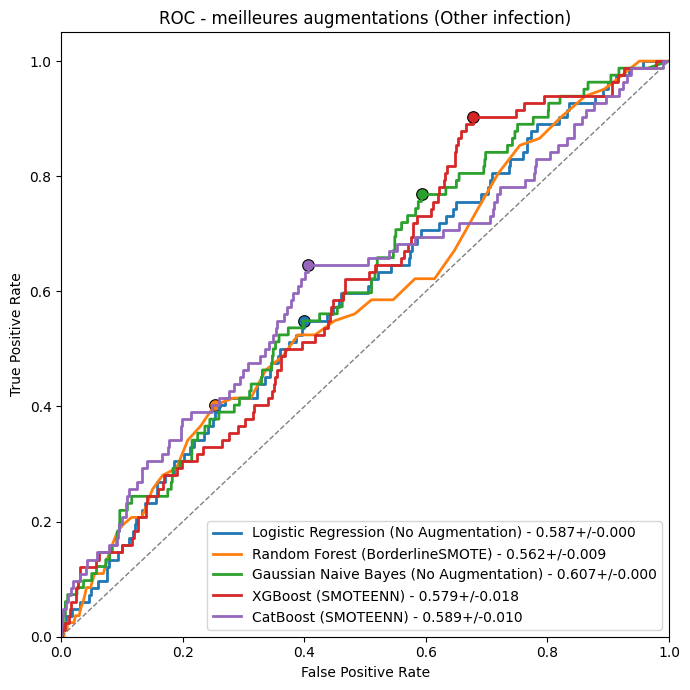

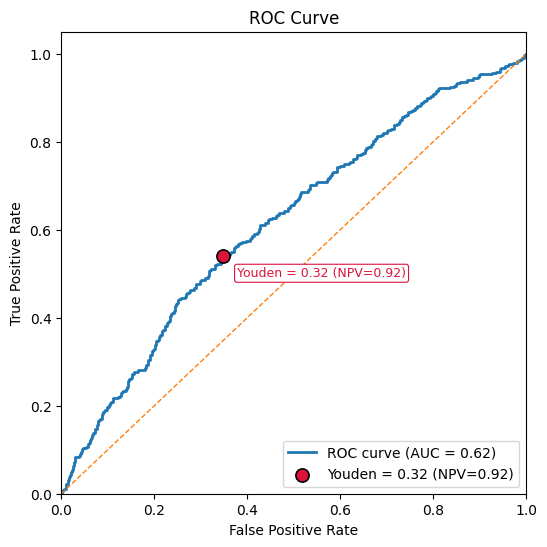

ROC AUC = 0.62
Negative Predictive Value youden: 0.9162742019884877 threshold 0.32205334875699765


c:\Users\romai\Desktop\codes\respiratory_diagnostics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


==== Other non infectious causes (split fourni) ====
Monte Carlo 1/10 (seed=42)

📊 Répartition des classes : pos=0.314, neg=0.686
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 2/10 (seed=43)

📊 Répartition des classes : pos=0.314, neg=0.686
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 3/10 (seed=44)

📊 Répartition des classes : pos=0.314, neg=0.686
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 4/10 (seed=45)

📊 Répartition des classes : pos=0.314, neg=0.686
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 5/10 (seed=46)

📊 Répartition des classes : pos=0.314, neg=0.686
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_weight ajouté

Monte Carlo 6/10 (seed=47)

📊 Répartition des classes : pos=0.314, neg=0.686
⚖️ Dataset déséquilibré ? → False
🙂 Dataset équilibré → aucun class_we

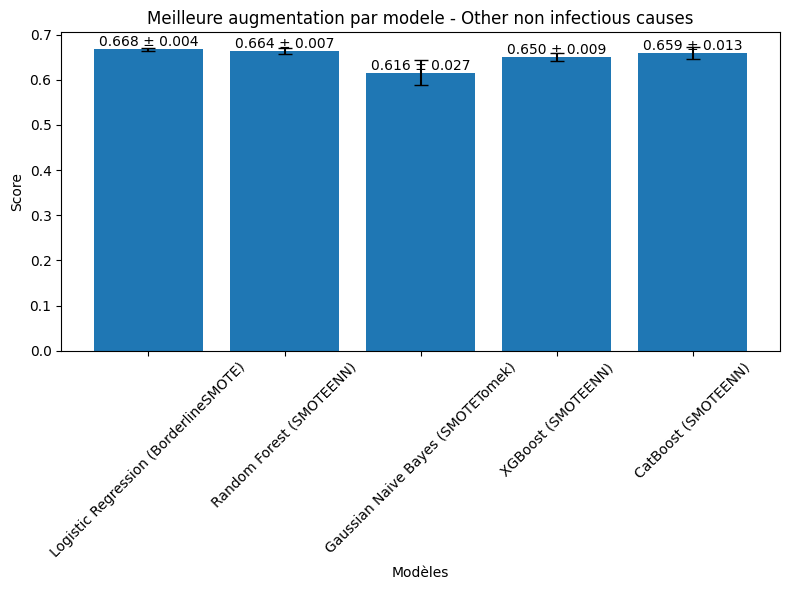


Courbes ROC des meilleures augmentations par modele :
- Logistic Regression (BorderlineSMOTE) - roc_auc moyen = 0.6677 +/- 0.0035 | seuil Youden = 0.6557
- Random Forest (SMOTEENN) - roc_auc moyen = 0.6640 +/- 0.0068 | seuil Youden = 0.6467
- Gaussian Naive Bayes (SMOTETomek) - roc_auc moyen = 0.6157 +/- 0.0272 | seuil Youden = 0.5446
- XGBoost (SMOTEENN) - roc_auc moyen = 0.6503 +/- 0.0094 | seuil Youden = 0.6805
- CatBoost (SMOTEENN) - roc_auc moyen = 0.6586 +/- 0.0128 | seuil Youden = 0.4401


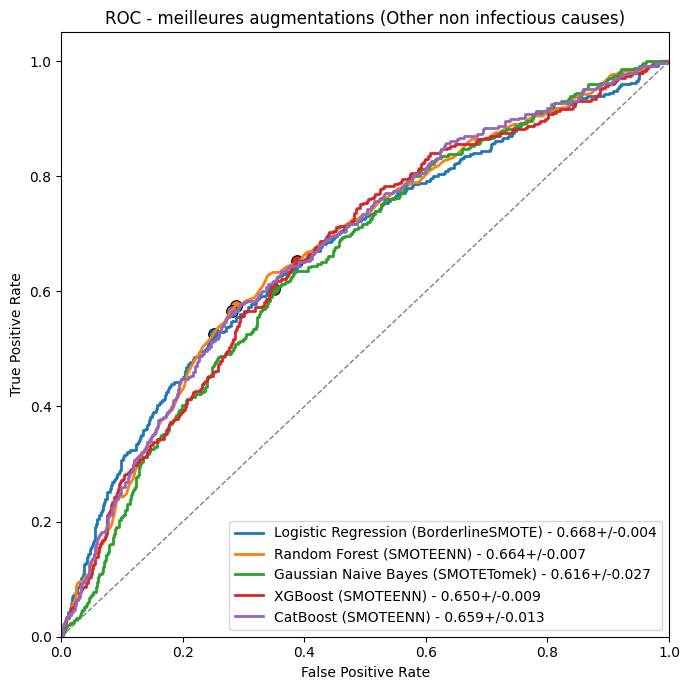

In [21]:
from utils.model_saving import save_model, load_model
from utils.validation import validation_save
import os 
diagnostique = 'Pneumocystis jirovecii infection'
save_dir = r"C:\Users\romai\Desktop\travail\avancement\model_grid_search\\"
for diagnostique in grroh_diag.columns:
    model_loaded = load_model(diagnostic =diagnostique,
                        model_dir = os.getcwd() + r'\models\\'
                        )
    # print(model_loaded["pipe_inference"].named_steps["scaler"].colonnes_numeriques)
    validation_save(diagnostique,
                        save_dir,
                        loaded = model_loaded,
                        grroh_features = grroh_features,
                        grroh_diag = grroh_diag,
                        df_features_clean = df_features_clean,
                        df_labels_fusion = df_labels_fusion
                        )


In [37]:
y_test.shape

(3032,)

In [95]:
for x in df_groh["DIAGPRINCIPAL_final.recod"].value_counts().index:
    try:
        float(x) 
        
    except:
        print(x)

BACT
BACT DOCU
UNDETERMINED
bact
EXTRA
UNKNOWN
infiltratif
BACT CLI
INFLUENZA
PCP
OAP
extra
INFILTRATIF
unknown
oap
aspiration
VIRUS
candidemie
AIRWAYS
airways
ASPIRATION
pcp
PLEURA
tox
pleura
TOX
IPA
influenza
ipa
copd
AUTRE
API
vrs
EP
pe
DRPT
VRS
RHINOVIRUS
PE
CMV
COPD
METAPNEUMOVIRUS
CORONAVIRUS
cmv
PIV3
parasite
ADENOVIRUS
bk
TRICHOSPORON
piv3
BACT DOCU + CAND
ENTEROVIRUS
MUCOR
NEUT RECOV
HSV
INFLuenza
coronavirus
rhinovirus
trichosporon


# Graphique de nom de maladie du sang

NameError: name 'plt' is not defined

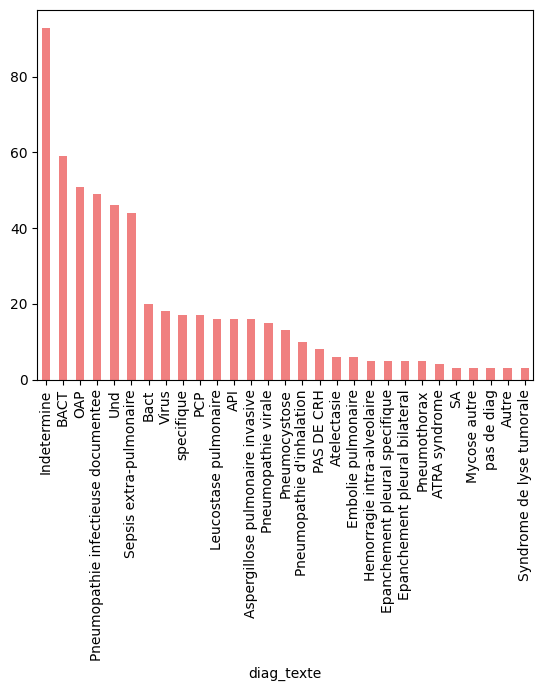

In [ ]:
df["diag_texte"].value_counts()[1:30].plot(kind='bar', color='lightcoral')
import matplotlib.pyplot as plt
plt.title("Distribution des diagnostiques")
plt.xlabel("diagnostiques")
plt.ylabel("Occurence")
plt.xticks(rotation=45, ha='right')
plt.show()